## LOGISTIC REGRESSION ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [2]:
def wraggle(data):
    
    data = pd.read_csv(data)

   

    # mapping customer type
    c_map = {"Loyal Customer":1, "disloyal Customer":2}
    data["Customer Type"] =   data["Customer Type"].map(c_map)


    # mapping travel type
    ttype_map = {"Personal Travel":1, "Business Travel":2}
    data["Type of Travel"] =   data["Type of Travel"].map(ttype_map).astype("Int64")


    # mapping class
    ctype_map = {"Eco":1, "Business":2, "Eco Plus" : 3}
    data["Class"] =  data["Class"].map(ctype_map)


    data = data.dropna()
    
    return data

In [3]:
df = wraggle('./data/airline.csv')

In [4]:
# df["Class"].unique()
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,1,65,1,1,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,1,47,1,2,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,1,15,1,1,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,1,60,1,1,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,1,70,1,1,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40042 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   satisfaction                       40042 non-null  object 
 1   Customer Type                      40042 non-null  int64  
 2   Age                                40042 non-null  int64  
 3   Type of Travel                     40042 non-null  Int64  
 4   Class                              40042 non-null  int64  
 5   Flight Distance                    40042 non-null  int64  
 6   Seat comfort                       40042 non-null  int64  
 7   Departure/Arrival time convenient  40042 non-null  int64  
 8   Food and drink                     40042 non-null  int64  
 9   Gate location                      40042 non-null  int64  
 10  Inflight wifi service              40042 non-null  int64  
 11  Inflight entertainment             40042 non-null  int64  

In [6]:
df.shape

(40042, 22)

## Examining The Satisfation

In [7]:
df["satisfaction"]

0            satisfied
1            satisfied
2            satisfied
3            satisfied
4            satisfied
              ...     
129875       satisfied
129876    dissatisfied
129877    dissatisfied
129878    dissatisfied
129879    dissatisfied
Name: satisfaction, Length: 40042, dtype: object

In [8]:
vc = df["satisfaction"].value_counts(normalize=True).sort_index()

## Visualization

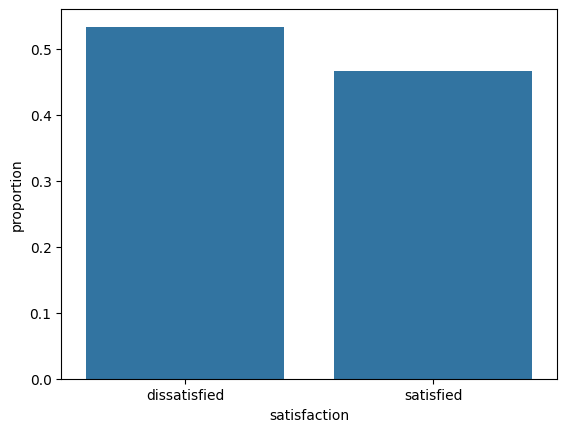

In [9]:
sns.barplot(vc);

In [10]:
y = df["satisfaction"]
X = df.drop(columns=["satisfaction"])

In [11]:
X_train, x_test, y_train, y_test =  train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
model = LogisticRegression(max_iter=1000)

In [13]:
model.fit(X_train, y_train)

/home/henorh/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(x_test)

In [15]:
set_map = {"dissatisfied":0, "satisfied":1}

In [16]:
mapped_y = y_test.map(set_map)

In [17]:
mapped_y

10100     1
129787    0
15592     0
31751     0
6844      0
         ..
28970     0
38566     1
8074      1
3298      0
25502     0
Name: satisfaction, Length: 8009, dtype: int64

In [18]:
ac_score =accuracy_score(y_test, y_pred)

In [19]:
ac_score

0.7936071919091022

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3549  788]
 [ 865 2807]]


In [21]:
clr = classification_report(y_test, y_pred)
print(clr)

              precision    recall  f1-score   support

dissatisfied       0.80      0.82      0.81      4337
   satisfied       0.78      0.76      0.77      3672

    accuracy                           0.79      8009
   macro avg       0.79      0.79      0.79      8009
weighted avg       0.79      0.79      0.79      8009



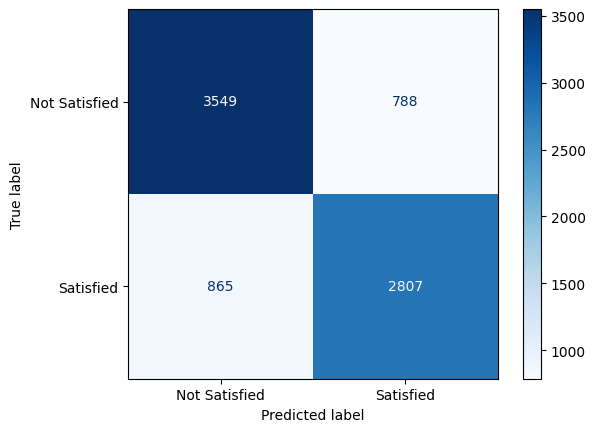

In [22]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Satisfied', 'Satisfied'])
cmd.plot(cmap='Blues')
plt.show()

In [23]:
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})

In [24]:
coef

,Feature,Coefficient,Odds_Ratio
0,Customer Type,-0.676218,0.508537
1,Age,-0.014766,0.985342
2,Type of Travel,-0.621375,0.537205
3,Class,-0.047028,0.954061
4,Flight Distance,-0.000621,0.999379
5,Seat comfort,0.463603,1.589792
6,Departure/Arrival time convenient,-0.338030,0.713174
7,Food and drink,-0.464554,0.628415
8,Gate location,0.095638,1.100361
9,Inflight wifi service,-0.143255,0.866533
